In [1]:
from pathlib import Path
import requests
import zipfile
import pandas as pd
import geopandas as gpd

# Project folders
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

geography_raw_dir = project_root / "data" / "raw" / "geography"
geography_raw_dir.mkdir(parents=True, exist_ok=True)

tract_zip_path = geography_raw_dir / "tl_2024_06_tract.zip"
tract_folder = geography_raw_dir / "tl_2024_06_tract"

# Official 2024 California Census tract boundary file
tract_url = (
    "https://www2.census.gov/geo/tiger/"
    "TIGER2024/TRACT/tl_2024_06_tract.zip"
)

print("Project root:", project_root)
print("Download destination:", tract_zip_path)

Project root: c:\Users\Scarl\Documents\portfolio\la_chinese_restaurant_site_selection
Download destination: c:\Users\Scarl\Documents\portfolio\la_chinese_restaurant_site_selection\data\raw\geography\tl_2024_06_tract.zip


In [2]:
# Download the official California tract boundary file

if not tract_zip_path.exists():
    response = requests.get(
        tract_url,
        timeout=120
    )
    response.raise_for_status()

    tract_zip_path.write_bytes(response.content)
    print("Boundary file downloaded.")
else:
    print("Boundary ZIP already exists; download skipped.")

print(
    "ZIP file size:",
    round(tract_zip_path.stat().st_size / 1024 / 1024, 2),
    "MB"
)

# Extract the ZIP file
tract_folder.mkdir(parents=True, exist_ok=True)

shapefile_path = tract_folder / "tl_2024_06_tract.shp"

if not shapefile_path.exists():
    with zipfile.ZipFile(tract_zip_path, "r") as zip_file:
        zip_file.extractall(tract_folder)

    print("Boundary file extracted.")
else:
    print("Extracted shapefile already exists; extraction skipped.")

print("Shapefile exists:", shapefile_path.exists())
print("Shapefile path:", shapefile_path)

Boundary file downloaded.
ZIP file size: 30.95 MB
Boundary file extracted.
Shapefile exists: True
Shapefile path: c:\Users\Scarl\Documents\portfolio\la_chinese_restaurant_site_selection\data\raw\geography\tl_2024_06_tract\tl_2024_06_tract.shp


In [3]:
# Read the statewide California Census tract boundaries

california_tracts = gpd.read_file(shapefile_path)

print("California tract rows:", len(california_tracts))
print("Coordinate system:", california_tracts.crs)
print("Duplicate GEOIDs:", california_tracts["GEOID"].duplicated().sum())

display(
    california_tracts[
        [
            "STATEFP",
            "COUNTYFP",
            "TRACTCE",
            "GEOID",
            "NAME",
            "geometry"
        ]
    ].head()
)

# Keep only Los Angeles County
la_tracts = california_tracts.loc[
    california_tracts["COUNTYFP"] == "037"
].copy()

print("\nLos Angeles County tract rows:", len(la_tracts))
print(
    "Unique Los Angeles County GEOIDs:",
    la_tracts["GEOID"].nunique()
)

California tract rows: 9129
Coordinate system: EPSG:4269
Duplicate GEOIDs: 0


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,geometry
0,06,001,442700,06001442700,4427,"POLYGON ((-122.01721 37.53932, -122.01719 37.5..."
1,06,001,442800,06001442800,4428,"POLYGON ((-122.0023 37.52984, -122.00224 37.52..."
2,06,037,204920,06037204920,2049.20,"POLYGON ((-118.20284 34.01966, -118.20283 34.0..."
3,06,037,205110,06037205110,2051.10,"POLYGON ((-118.21964 34.02628, -118.21945 34.0..."
4,06,037,205120,06037205120,2051.20,"POLYGON ((-118.22023 34.02056, -118.22018 34.0..."



Los Angeles County tract rows: 2498
Unique Los Angeles County GEOIDs: 2498


In [6]:
# Locate the demographic CSV inside the project

file_name = "acs_2024_la_county_tract_demographics.csv"

matches = list(
    project_root.rglob(file_name)
)

print("Files found:", len(matches))

for file_path in matches:
    print(file_path)

Files found: 1
c:\Users\Scarl\Documents\portfolio\la_chinese_restaurant_site_selection\notebooks\data\processed\acs_2024_la_county_tract_demographics.csv


In [7]:
# Use the demographic file found in the project

demographic_path = matches[0]

print("Using demographic file:")
print(demographic_path)

# Load the processed ACS demographic table
demographics = pd.read_csv(
    demographic_path,
    dtype={
        "geoid": "string",
        "state": "string",
        "county": "string",
        "tract": "string"
    }
)

print("\nDemographic rows:", len(demographics))
print(
    "Unique demographic GEOIDs:",
    demographics["geoid"].nunique()
)

# Compare the geographic keys before joining
boundary_geoids = set(la_tracts["GEOID"])
demographic_geoids = set(demographics["geoid"])

print(
    "Boundaries without demographics:",
    len(boundary_geoids - demographic_geoids)
)

print(
    "Demographics without boundaries:",
    len(demographic_geoids - boundary_geoids)
)

# Join demographics to tract geometry
la_tract_demographics = la_tracts.merge(
    demographics,
    left_on="GEOID",
    right_on="geoid",
    how="left",
    validate="one_to_one",
    indicator=True
)

print("\nJoined rows:", len(la_tract_demographics))

display(
    la_tract_demographics["_merge"]
    .value_counts()
    .rename_axis("join_status")
    .reset_index(name="tract_count")
)

Using demographic file:
c:\Users\Scarl\Documents\portfolio\la_chinese_restaurant_site_selection\notebooks\data\processed\acs_2024_la_county_tract_demographics.csv

Demographic rows: 2498
Unique demographic GEOIDs: 2498
Boundaries without demographics: 0
Demographics without boundaries: 0

Joined rows: 2498


,join_status,tract_count
0,both,2498
1,left_only,0
2,right_only,0


In [9]:
# Prepare the spatial table for GeoPackage export

la_tract_demographics_clean = (
    la_tract_demographics
    .drop(
        columns=["_merge", "geoid"],
        errors="ignore"
    )
    .copy()
)

# Confirm that field names are unique even when case is ignored
lowercase_field_names = [
    column.lower()
    for column in la_tract_demographics_clean.columns
]

print(
    "Case-insensitive duplicate field names:",
    len(lowercase_field_names)
    - len(set(lowercase_field_names))
)

geopackage_path = (
    processed_dir
    / "la_tract_demographics_2024.gpkg"
)

# Remove the incomplete file left by the failed export
if geopackage_path.exists():
    geopackage_path.unlink()
    print("Incomplete GeoPackage removed.")

# Save the corrected spatial dataset
la_tract_demographics_clean.to_file(
    geopackage_path,
    layer="la_tract_demographics",
    driver="GPKG",
    index=False
)

print("Spatial rows saved:", len(la_tract_demographics_clean))
print("GeoPackage exists:", geopackage_path.exists())
print("GeoPackage path:", geopackage_path)

Case-insensitive duplicate field names: 0
Incomplete GeoPackage removed.
Spatial rows saved: 2498
GeoPackage exists: True
GeoPackage path: c:\Users\Scarl\Documents\portfolio\la_chinese_restaurant_site_selection\data\processed\la_tract_demographics_2024.gpkg


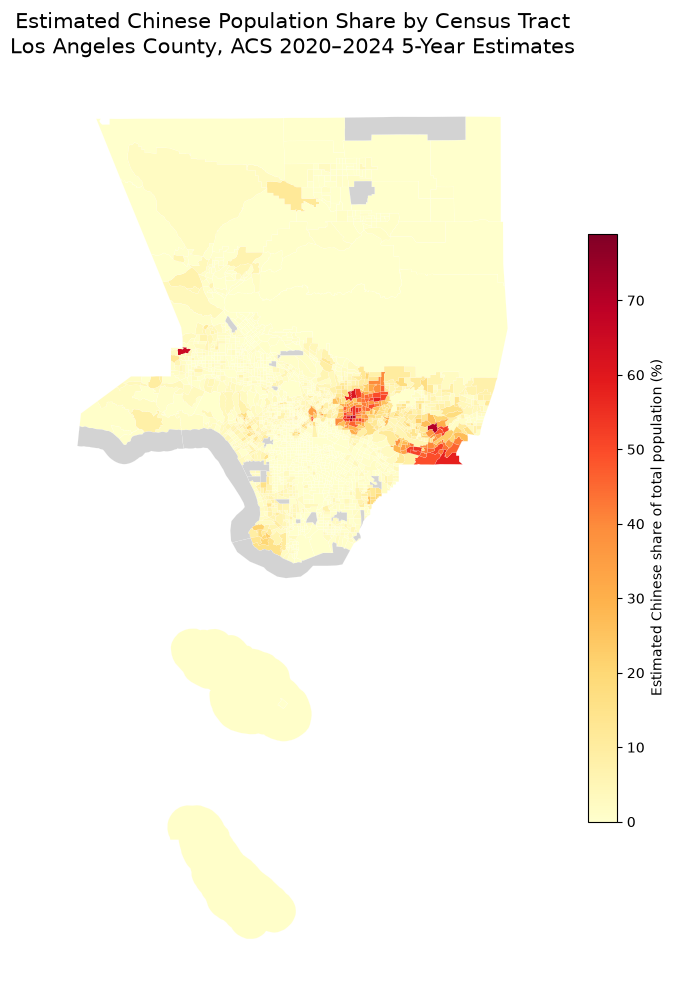

Map saved to: c:\Users\Scarl\Documents\portfolio\la_chinese_restaurant_site_selection\visuals\la_chinese_population_share_tracts.png


In [10]:
import matplotlib.pyplot as plt

# Create the first demographic demand map

fig, ax = plt.subplots(
    figsize=(12, 10)
)

la_tract_demographics_clean.plot(
    column="chinese_share_pct",
    cmap="YlOrRd",
    linewidth=0.08,
    edgecolor="white",
    legend=True,
    missing_kwds={
        "color": "lightgray",
        "label": "No population or unavailable"
    },
    legend_kwds={
        "label": "Estimated Chinese share of total population (%)",
        "shrink": 0.65
    },
    ax=ax
)

ax.set_title(
    "Estimated Chinese Population Share by Census Tract\n"
    "Los Angeles County, ACS 2020–2024 5-Year Estimates",
    fontsize=15,
    pad=16
)

ax.set_axis_off()

plt.tight_layout()

# Save the map image
map_path = (
    project_root
    / "visuals"
    / "la_chinese_population_share_tracts.png"
)

map_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Map saved to:", map_path)

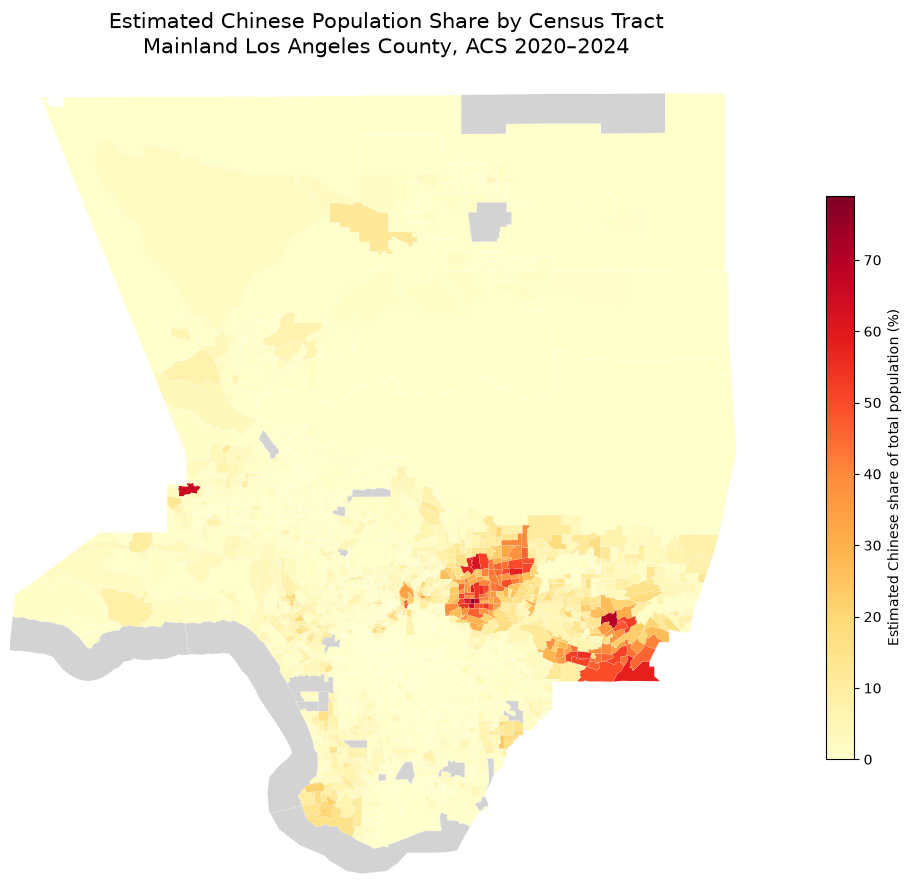

Focused map saved to: c:\Users\Scarl\Documents\portfolio\la_chinese_restaurant_site_selection\visuals\la_chinese_population_share_mainland.png


In [11]:
# Create a mainland-focused exploratory map

fig, ax = plt.subplots(
    figsize=(13, 9)
)

la_tract_demographics_clean.plot(
    column="chinese_share_pct",
    cmap="YlOrRd",
    linewidth=0.08,
    edgecolor="white",
    legend=True,
    missing_kwds={
        "color": "lightgray",
        "label": "No population or unavailable"
    },
    legend_kwds={
        "label": "Estimated Chinese share of total population (%)",
        "shrink": 0.70
    },
    ax=ax
)

# Focus on mainland Los Angeles County
ax.set_xlim(-118.95, -117.60)
ax.set_ylim(33.65, 34.85)

ax.set_title(
    "Estimated Chinese Population Share by Census Tract\n"
    "Mainland Los Angeles County, ACS 2020–2024",
    fontsize=15,
    pad=16
)

ax.set_axis_off()
plt.tight_layout()

focused_map_path = (
    project_root
    / "visuals"
    / "la_chinese_population_share_mainland.png"
)

plt.savefig(
    focused_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Focused map saved to:", focused_map_path)